Verification

In [39]:
import os
import cv2
import numpy as np
import pytesseract
import tesserocr
from PIL import Image
from tesserocr import PyTessBaseAPI, PSM, OEM

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
DEFAULT_DIR = "C:/Program Files/Tesseract-OCR/tessdata/"
BEST_DIR = "C:/tessdata_best/"

print("OpenCV      :", cv2.__version__)
print("pytesseract :", pytesseract.get_tesseract_version())
print("tesserocr   :", tesserocr.tesseract_version().splitlines()[0])

default_path, langs = tesserocr.get_languages(DEFAULT_DIR)
print("Default tessdata:", default_path)
for name in ["ben", "eng", "osd"]:
    print(f"  {name:4s} ->", "OK" if name in langs else "MISSING")

best_path, best_langs = tesserocr.get_languages(BEST_DIR)
print("tessdata_best   :", best_path, best_langs)

img = np.full((80, 400), 255, np.uint8)
cv2.putText(img, "1990-05-12", (20, 55), cv2.FONT_HERSHEY_SIMPLEX, 1.5, 0, 3)

with PyTessBaseAPI(path=BEST_DIR, lang="eng", psm=PSM.SINGLE_LINE, oem=OEM.LSTM_ONLY) as api:
    api.SetImage(Image.fromarray(img))
    print("tesserocr smoke test  :", api.GetUTF8Text().strip())

print("pytesseract smoke test:", pytesseract.image_to_string(img, lang="eng", config="--psm 7").strip())

OpenCV      : 5.0.0
pytesseract : 5.5.3.20260724
tesserocr   : tesseract 5.3.4
Default tessdata: C:/Program Files/Tesseract-OCR/tessdata/
  ben  -> OK
  eng  -> OK
  osd  -> OK
tessdata_best   : C:/tessdata_best/ ['ben', 'eng', 'osd']
tesserocr smoke test  : 1990-05-12
pytesseract smoke test: 1990-05-12


### Stage 1: Load Image

The input image is loaded into **Leptonica's** in-memory image format (`PIX`). Then, Leptonica performs two preparatory steps:

1. **Reads the resolution:** extracts the image's DPI metadata, which is used for scaling and layout analysis in later stages.
2. **Creates a grayscale copy:** converts the image to 8-bit grayscale so downstream processing works on a single intensity channel.

Stage 1 output
  File          : images\19a.jpg
  Colour mode   : RGB
  Size (W x H)  : 1790 x 1187 px
  Resolution    : not stored in file (Tesseract will estimate it)
  Grayscale copy: shape (1187, 1790), dtype uint8, range 0-251  [rebuilt here]

  Passed to Stage 2 -> the loaded image


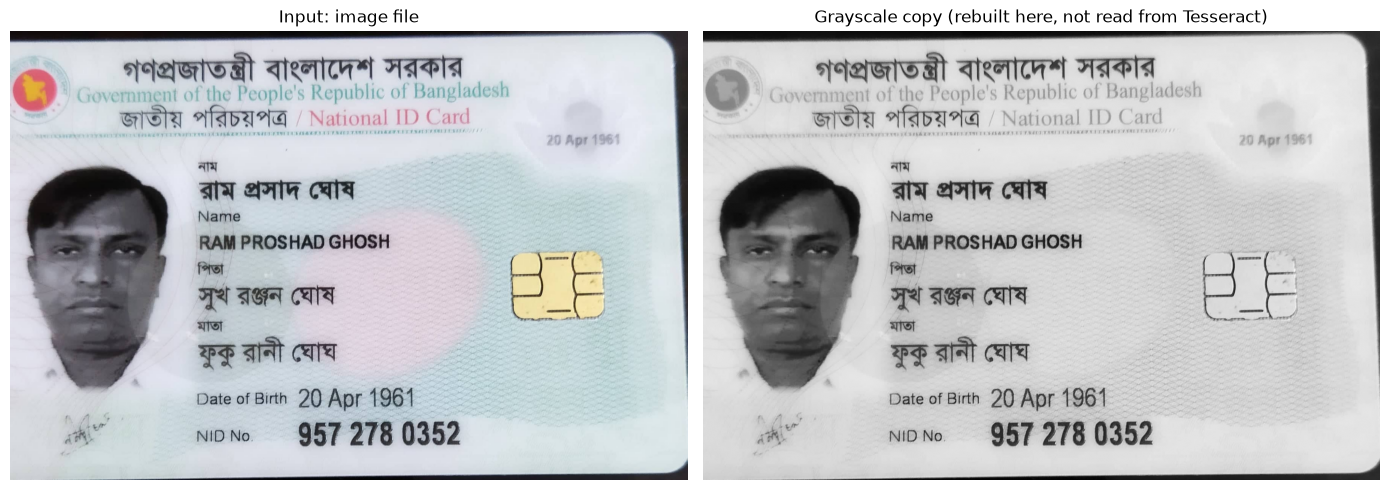

In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tesserocr import PyTessBaseAPI, PSM, OEM

IMG_PATH = os.path.join("images", "19a.jpg")
TESSDATA_DIR = "C:/tessdata_best/"
LANG = "ben+eng"
PSM_MODE = PSM.AUTO
OEM_MODE = OEM.LSTM_ONLY

pil_img = Image.open(IMG_PATH)
pil_img.load()
file_dpi = pil_img.info.get("dpi")

if "api" in globals():
    api.End()
api = PyTessBaseAPI(path=TESSDATA_DIR, lang=LANG, psm=PSM_MODE, oem=OEM_MODE)
api.SetImageFile(IMG_PATH)

rgb = np.asarray(pil_img.convert("RGB"), dtype=np.float32)
gray = np.clip(0.3 * rgb[..., 0] + 0.5 * rgb[..., 1] + 0.2 * rgb[..., 2] + 0.5, 0, 255).astype(np.uint8)

BOX_THICKNESS = max(1, round(pil_img.width / 700))

print("Stage 1 output")
print(f"  File          : {IMG_PATH}")
print(f"  Colour mode   : {pil_img.mode}")
print(f"  Size (W x H)  : {pil_img.width} x {pil_img.height} px")
print(f"  Resolution    : {file_dpi if file_dpi else 'not stored in file (Tesseract will estimate it)'}")
print(f"  Grayscale copy: shape {gray.shape}, dtype {gray.dtype}, range {gray.min()}-{gray.max()}  [rebuilt here]")
print("\n  Passed to Stage 2 -> the loaded image")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(pil_img)
axes[0].set_title("Input: image file")
axes[1].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Grayscale copy (rebuilt here, not read from Tesseract)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Stage 2: Thresholding

The grayscale copy is converted into a **binary (1-bit)** image by **Otsu's method**, which picks a single brightness value separating ink from background. Two points follow from this:

1. **One threshold for the whole image:** any pixel darker than the chosen value becomes ink, whether it is text or not.
2. **Two images move forward:** the binary image drives Stages 3–7, while the grayscale copy is kept for the recognizer in Stage 8.

Stage 2 output
  Binary image from Tesseract : shape (1187, 1790), ink pixels 16.33%
  Single-value Otsu threshold : 141  [computed here with OpenCV,
                                 for illustration - not the value Tesseract used]

  Passed to Stage 3 -> binary_img


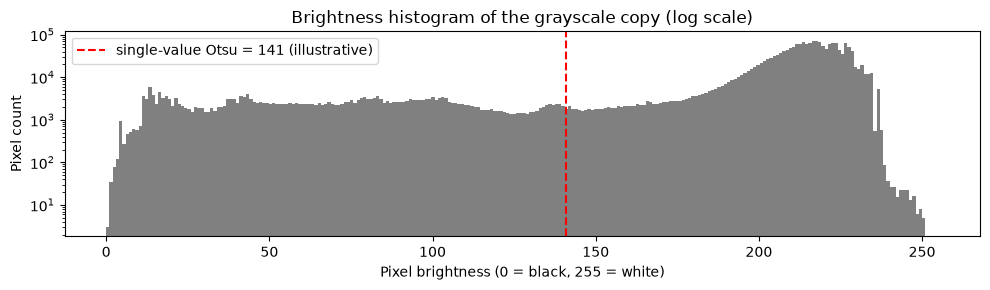

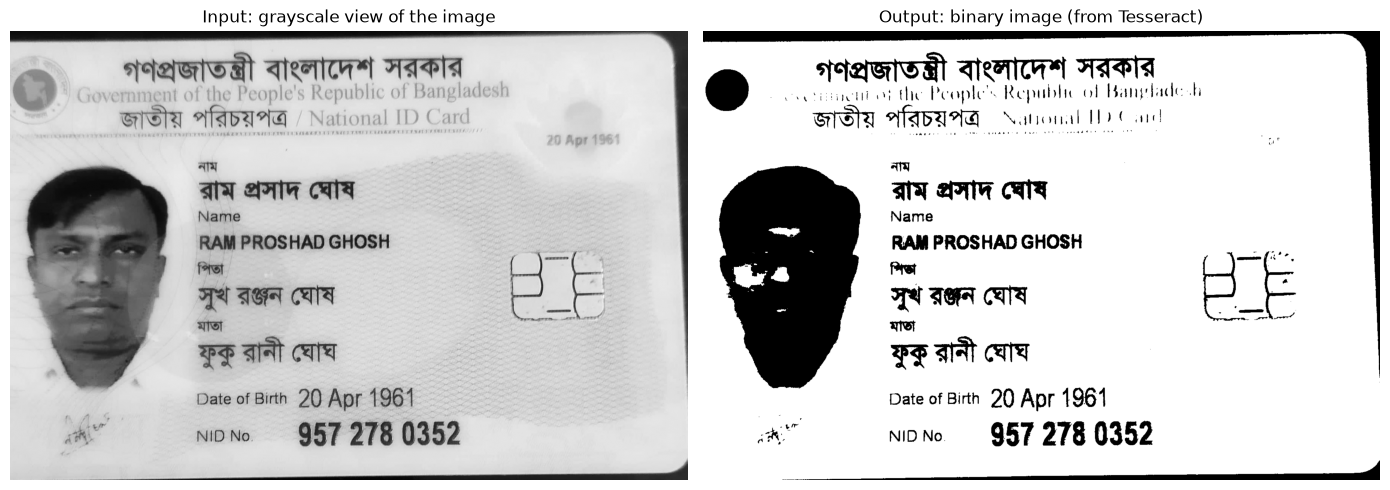

In [41]:
import cv2


with PyTessBaseAPI(path=TESSDATA_DIR, lang=LANG, psm=PSM_MODE, oem=OEM_MODE) as tmp_api:
    tmp_api.SetImageFile(IMG_PATH)
    binary_img = np.array(tmp_api.GetThresholdedImage().convert("L"))


illustrative_otsu, _ = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


ink_pct = 100 * np.mean(binary_img == 0)
print("Stage 2 output")
print(f"  Binary image from Tesseract : shape {binary_img.shape}, ink pixels {ink_pct:.2f}%")
print(f"  Single-value Otsu threshold : {illustrative_otsu:.0f}  [computed here with OpenCV,")
print( "                                 for illustration - not the value Tesseract used]")
print("\n  Passed to Stage 3 -> binary_img")

plt.figure(figsize=(10, 3))
plt.hist(gray.ravel(), bins=256, range=(0, 255), color="gray")
plt.axvline(illustrative_otsu, color="red", linestyle="--",
            label=f"single-value Otsu = {illustrative_otsu:.0f} (illustrative)")
plt.yscale("log")
plt.title("Brightness histogram of the grayscale copy (log scale)")
plt.xlabel("Pixel brightness (0 = black, 255 = white)")
plt.ylabel("Pixel count")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Input: grayscale view of the image")
axes[1].imshow(binary_img, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Output: binary image (from Tesseract)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Stage 3: Connected-Component Analysis

The binary image is scanned for **connected components**: groups of touching black pixels, called **blobs**. Each blob is then measured and filtered:

1. **Measures each blob:** records a bounding box, pixel count and size for every group found.
2. **Discards non-text blobs:** drops tiny specks as noise, and removes blobs too large or the wrong shape to be characters, such as photographs, ruled lines and logos.

Stage 3 output
  Raw components in the binary image : 374   [OpenCV, unfiltered]
  Components Tesseract keeps as text : 198   [text-only, after layout analysis]
  Blob width  (px): min 2, median 16, max 94
  Blob height (px): min 2, median 37, max 81

  First 5 blobs:
    x=  301  y=   84  w=  25  h=  35
    x=  327  y=   76  w=  16  h=  60
    x=  344  y=   74  w=  48  h=  61
    x=  388  y=   76  w=  52  h=  62
    x=  441  y=   82  w=  61  h=  52

  Passed to Stages 4-5 -> boxes


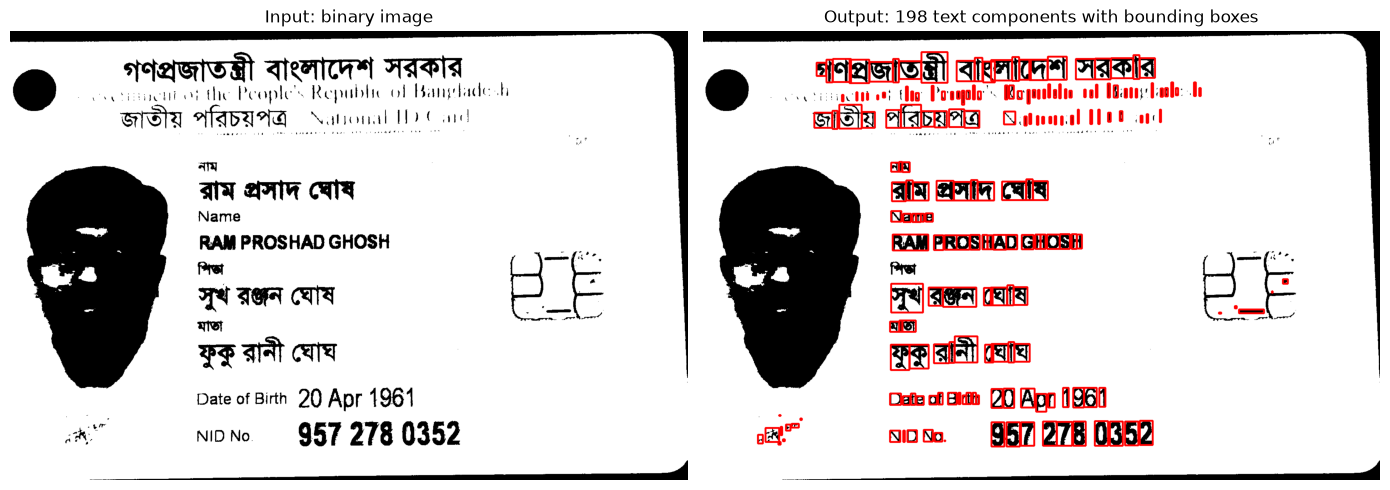

In [42]:
components = api.GetConnectedComponents()
boxes = [c[1] for c in components]

ink_mask = (binary_img == 0).astype(np.uint8)
n_raw, _, stats, _ = cv2.connectedComponentsWithStats(ink_mask, connectivity=8)

widths = np.array([b["w"] for b in boxes])
heights = np.array([b["h"] for b in boxes])


print("Stage 3 output")
print(f"  Raw components in the binary image : {n_raw - 1:,}   [OpenCV, unfiltered]")
print(f"  Components Tesseract keeps as text : {len(boxes):,}   [text-only, after layout analysis]")
print(f"  Blob width  (px): min {widths.min()}, median {int(np.median(widths))}, max {widths.max()}")
print(f"  Blob height (px): min {heights.min()}, median {int(np.median(heights))}, max {heights.max()}")
print("\n  First 5 blobs:")
for b in boxes[:5]:
    print(f"    x={b['x']:5d}  y={b['y']:5d}  w={b['w']:4d}  h={b['h']:4d}")
print("\n  Passed to Stages 4-5 -> boxes")

overlay = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2RGB)
for b in boxes:
    cv2.rectangle(overlay, (b["x"], b["y"]), (b["x"] + b["w"], b["y"] + b["h"]),
                  (255, 0, 0), BOX_THICKNESS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(binary_img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Input: binary image")
axes[1].imshow(overlay)
axes[1].set_title(f"Output: {len(boxes):,} text components with bounding boxes")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Stage 4: Orientation and Script Detection (Only for PSM 1)

The blobs are examined to work out how the page is turned and what writing system it uses. This stage runs only in PSM 0, 1 and 12, using the separate `osd.traineddata` model:

1. **Detects orientation:** tests the blobs at 0°, 90°, 180° and 270° and reports which rotation reads correctly, with a confidence score.
2. **Detects script:** identifies the writing system, such as Bengali or Latin, with its own confidence score.

A detected rotation is applied before the remaining stages run.

*Note: this notebook's main pipeline runs at PSM 3, where this stage never executes. The cell below uses a separate Tesseract object in PSM 0 to demonstrate it.*

Stage 4 output
  image as loaded:
    Rotation needed : 0 degrees clockwise (confidence 3.29)
    Script detected : Bengali (confidence 0.56)
  same image turned 90 degrees:
    Rotation needed : 270 degrees clockwise (confidence 3.28)
    Script detected : Bengali (confidence 4.44)

  This stage is skipped at PSM 3, so Stage 5 continues from Stage 3's blobs unchanged.


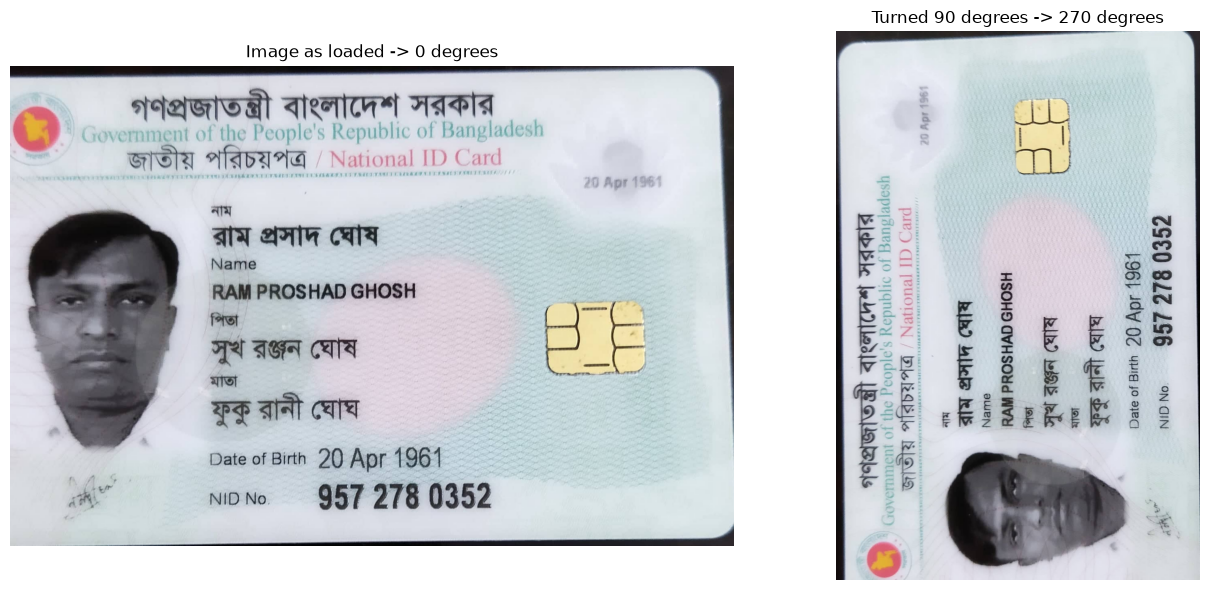

In [43]:
with PyTessBaseAPI(path=TESSDATA_DIR, lang="osd", psm=PSM.OSD_ONLY) as osd_api:
    osd_api.SetImageFile(IMG_PATH)
    osd_upright = osd_api.DetectOrientationScript()

rotated = pil_img.rotate(90, expand=True)
with PyTessBaseAPI(path=TESSDATA_DIR, lang="osd", psm=PSM.OSD_ONLY) as osd_api:
    osd_api.SetImage(rotated)
    osd_rotated = osd_api.DetectOrientationScript()


print("Stage 4 output")
for label, result in [("image as loaded", osd_upright), ("same image turned 90 degrees", osd_rotated)]:
    print(f"  {label}:")
    if result is None:
        print("    no result - too few blobs for OSD to decide")
        continue
    print(f"    Rotation needed : {result['orient_deg']} degrees clockwise (confidence {result['orient_conf']:.2f})")
    print(f"    Script detected : {result['script_name']} (confidence {result['script_conf']:.2f})")
print("\n  This stage is skipped at PSM 3, so Stage 5 continues from Stage 3's blobs unchanged.")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(pil_img)
axes[0].set_title(f"Image as loaded -> {osd_upright['orient_deg'] if osd_upright else '?'} degrees")
axes[1].imshow(rotated)
axes[1].set_title(f"Turned 90 degrees -> {osd_rotated['orient_deg'] if osd_rotated else '?'} degrees")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Stage 5: Page Layout Analysis

The blobs are grouped into **blocks**: rectangular regions that each hold one kind of content. Three things happen here:

1. **Finds columns:** locates tab stops and vertical alignments to work out how the page is divided.
2. **Classifies each region:** labels every block as flowing text, a heading, an image, a separator line or noise.
3. **Sets reading order:** arranges the text blocks in the order a person would read them.

Only text blocks continue to Stage 6. Images, lines and noise are set aside here.

Stage 5 output
  Blocks found      : 16
  Text blocks kept  : 11

  Blocks in reading order:
     1. FLOWING_IMAGE    set aside  x= 885 y=   0 w= 905 h= 179
     2. HORZ_LINE        set aside  x=   0 y=   0 w= 888 h=  36
     3. FLOWING_TEXT     text       x= 301 y=  56 w= 894 h=  82
     4. FLOWING_TEXT     text       x= 354 y= 136 w= 962 h=  59
     5. FLOWING_TEXT     text       x= 291 y= 195 w= 920 h=  64
     6. FLOWING_IMAGE    set aside  x=   4 y= 108 w= 122 h= 108
     7. FLOWING_TEXT     text       x= 498 y= 346 w=  49 h=  27
     8. FLOWING_TEXT     text       x= 500 y= 392 w= 412 h=  58
     9. FLOWING_TEXT     text       x= 498 y= 476 w= 110 h=  29
    10. FLOWING_TEXT     text       x= 502 y= 537 w= 500 h=  43
    11. FLOWING_TEXT     text       x= 498 y= 656 w=1048 h=  91
    12. FLOWING_TEXT     text       x= 495 y= 765 w=  68 h=  30
    13. FLOWING_TEXT     text       x= 497 y= 807 w= 367 h=  89
    14. FLOWING_TEXT     text       x= 146 y= 943 w=1043 h= 155
    15. FLO

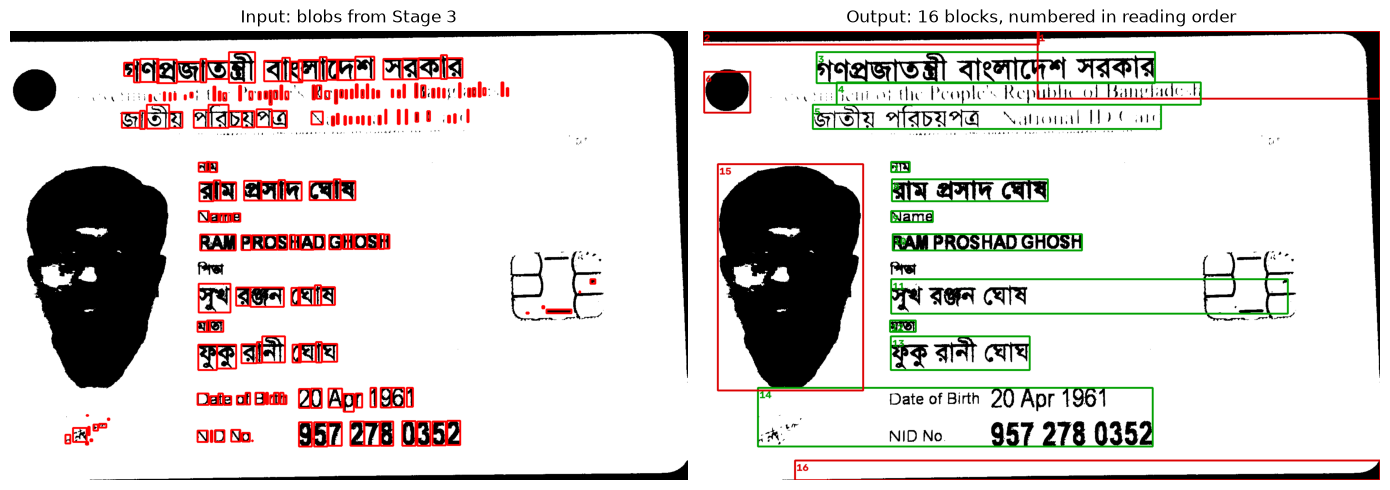

In [44]:
from tesserocr import RIL, PT

api.SetImageFile(IMG_PATH)
layout = api.AnalyseLayout()

pt_names = {getattr(PT, n): n for n in dir(PT) if not n.startswith("_") and isinstance(getattr(PT, n), int)}


blocks = []
if layout is not None:
    layout.Begin()
    while True:
        box = layout.BoundingBox(RIL.BLOCK)
        if box is not None:
            code = layout.BlockType()
            blocks.append({"box": box, "code": code, "type": pt_names.get(code, str(code))})
        if not layout.Next(RIL.BLOCK):
            break

text_blocks = [b for b in blocks if "TEXT" in b["type"]]


print("Stage 5 output")
print(f"  Blocks found      : {len(blocks)}")
print(f"  Text blocks kept  : {len(text_blocks)}")
print("\n  Blocks in reading order:")
for i, b in enumerate(blocks, 1):
    x0b, y0b, x1b, y1b = b["box"]
    kept = "text" if "TEXT" in b["type"] else "set aside"
    print(f"    {i:2d}. {b['type']:16s} {kept:10s} x={x0b:4d} y={y0b:4d} w={x1b - x0b:4d} h={y1b - y0b:4d}")
print("\n  Passed to Stage 6 -> text_blocks")

overlay5 = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2RGB)
for i, b in enumerate(blocks, 1):
    x0b, y0b, x1b, y1b = b["box"]
    colour = (0, 160, 0) if "TEXT" in b["type"] else (220, 0, 0)
    cv2.rectangle(overlay5, (x0b, y0b), (x1b, y1b), colour, BOX_THICKNESS + 1)
    cv2.putText(overlay5, str(i), (x0b + 4, y0b + 28), cv2.FONT_HERSHEY_SIMPLEX, 0.9, colour, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(overlay)
axes[0].set_title("Input: blobs from Stage 3")
axes[1].imshow(overlay5)
axes[1].set_title(f"Output: {len(blocks)} blocks, numbered in reading order")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Stage 6: Line Finding

Within each text block, the blobs are grouped into **text lines**. Four measurements are made:

1. **Estimates skew:** works out how much the text tilts, so slightly rotated lines are still grouped correctly.
2. **Groups blobs into rows:** collects blobs that sit at the same vertical level into one line.
3. **Fits a baseline:** fits a curve along the bottom of the line, which may bend if the page is warped.
4. **Estimates x-height:** measures the height of the main body of the text, used to tell characters from marks.

Small marks that sit above or below the main body, such as dots and diacritics, are attached to the line they belong to.

Stage 6 output
  Text lines found : 17
  Line height (px) : min 27, median 64, max 598

  Lines in reading order:
     1. x= 885 y=   0 w= 905 h=179  baseline tilt +0.00 deg
     2. x=   0 y=   0 w= 888 h= 36  baseline tilt +0.00 deg
     3. x= 301 y=  56 w= 894 h= 82  baseline tilt -0.77 deg
     4. x= 354 y= 136 w= 962 h= 59  baseline tilt -0.85 deg
     5. x= 291 y= 195 w= 920 h= 64  baseline tilt -1.19 deg
     6. x=   4 y= 108 w= 122 h=108  baseline tilt +0.00 deg
     7. x= 498 y= 346 w=  49 h= 27  baseline tilt +1.17 deg
     8. x= 500 y= 392 w= 412 h= 58  baseline tilt -0.28 deg
     9. x= 498 y= 476 w= 110 h= 29  baseline tilt -0.52 deg
    10. x= 502 y= 537 w= 500 h= 43  baseline tilt -0.57 deg
    11. x= 498 y= 656 w=1048 h= 91  baseline tilt -0.60 deg
    12. x= 495 y= 765 w=  68 h= 30  baseline tilt +0.00 deg
    13. x= 497 y= 807 w= 367 h= 89  baseline tilt -0.78 deg
    14. x= 202 y= 943 w= 862 h= 85  baseline tilt -0.27 deg
    15. x= 146 y=1030 w=1043 h= 68  baseline t

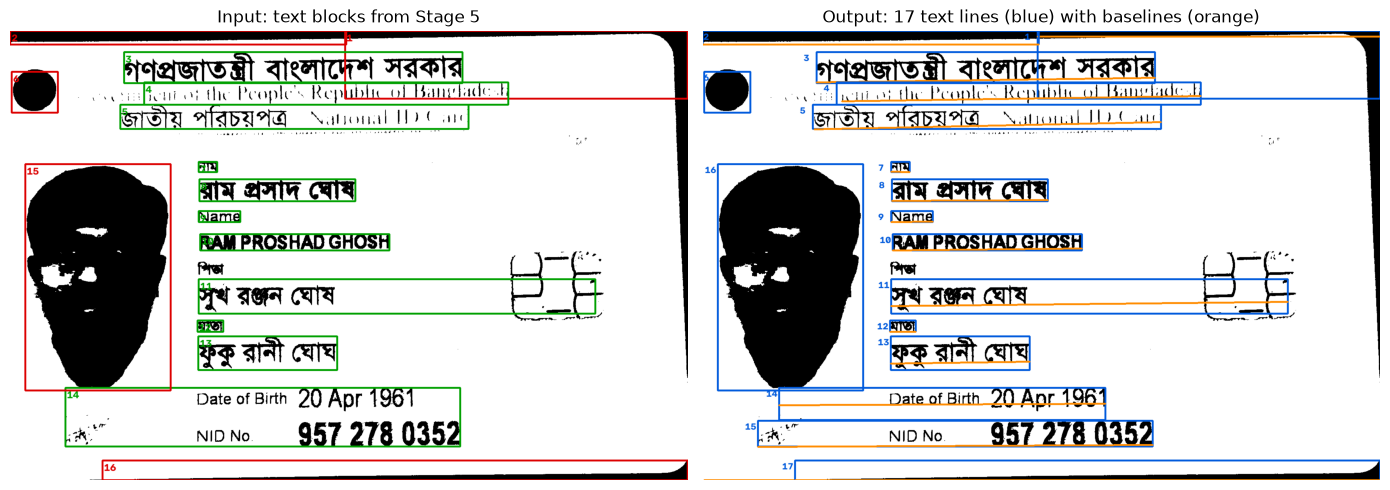

In [45]:
api.SetImageFile(IMG_PATH)
layout = api.AnalyseLayout()

lines = []
if layout is not None:
    layout.Begin()
    while True:
        box = layout.BoundingBox(RIL.TEXTLINE)
        if box is not None:
            entry = {"box": box}
            try:
                entry["baseline"] = layout.Baseline(RIL.TEXTLINE)
            except Exception:
                entry["baseline"] = None
            lines.append(entry)
        if not layout.Next(RIL.TEXTLINE):
            break


for ln in lines:
    x0b, y0b, x1b, y1b = ln["box"]
    ln["w"] = x1b - x0b
    ln["h"] = y1b - y0b
    if ln["baseline"]:
        (bx0, by0), (bx1, by1) = ln["baseline"]
        ln["tilt"] = np.degrees(np.arctan2(by1 - by0, max(bx1 - bx0, 1)))
    else:
        ln["tilt"] = None


heights6 = np.array([ln["h"] for ln in lines])
print("Stage 6 output")
print(f"  Text lines found : {len(lines)}")
if len(lines):
    print(f"  Line height (px) : min {heights6.min()}, median {int(np.median(heights6))}, max {heights6.max()}")
print("\n  Lines in reading order:")
for i, ln in enumerate(lines, 1):
    x0b, y0b, _, _ = ln["box"]
    tilt = f"{ln['tilt']:+.2f} deg" if ln["tilt"] is not None else "n/a"
    print(f"    {i:2d}. x={x0b:4d} y={y0b:4d} w={ln['w']:4d} h={ln['h']:3d}  baseline tilt {tilt}")
print("\n  Passed to Stage 7 -> lines")
print("  The baseline and x-height measured here are also used in Stage 8.")

overlay6 = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2RGB)
for i, ln in enumerate(lines, 1):
    x0b, y0b, x1b, y1b = ln["box"]
    cv2.rectangle(overlay6, (x0b, y0b), (x1b, y1b), (0, 90, 220), BOX_THICKNESS)
    if ln["baseline"]:
        (bx0, by0), (bx1, by1) = ln["baseline"]
        cv2.line(overlay6, (bx0, by0), (bx1, by1), (255, 140, 0), BOX_THICKNESS + 1)
    cv2.putText(overlay6, str(i), (max(x0b - 34, 2), y0b + 24),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 90, 220), 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(overlay5)
axes[0].set_title("Input: text blocks from Stage 5")
axes[1].imshow(overlay6)
axes[1].set_title(f"Output: {len(lines)} text lines (blue) with baselines (orange)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Stage 7: Word Finding

Each text line is split into **words** by examining the gaps between blobs:

1. **Measures the gaps:** records the horizontal distance between neighbouring blobs along the line.
2. **Classifies each gap:** decides whether a gap is a space between words or just the normal spacing between characters, judged relative to the line's own character size.

The resulting word boxes are what the legacy engine recognizes. The LSTM engine reads the whole line instead and decides spaces itself, so these boxes mainly serve as position information.

Stage 7 output
  Words found : 64
  Gap between neighbouring words (px): min -804, median 21, max 506

  Words per line:
    line  1: 7 word(s)   widths: 176, 905, 209, 35, 105, 97, 28
    line  2: 1 word(s)   widths: 888
    line  3: 2 word(s)   widths: 346, 291
    line  4: 5 word(s)   widths: 35, 42, 35, 59, 169
    line  5: 10 word(s)   widths: 164, 246, 46, 113, 21, 25, 7, 7, 50, 21
    line  6: 1 word(s)   widths: 122
    line  7: 1 word(s)   widths: 49
    line  8: 3 word(s)   widths: 97, 152, 121
    line  9: 4 word(s)   widths: 27, 20, 31, 19
    line 10: 3 word(s)   widths: 94, 220, 159
    line 11: 7 word(s)   widths: 84, 126, 115, 6, 77, 2, 13
    line 12: 1 word(s)   widths: 68
    line 13: 3 word(s)   widths: 100, 115, 118
    line 14: 8 word(s)   widths: 4, 4, 89, 35, 82, 60, 89, 112
    line 15: 6 word(s)   widths: 108, 71, 57, 113, 113, 153
    line 16: 1 word(s)   widths: 384
    line 17: 1 word(s)   widths: 1546

  Passed to Stage 8 -> words


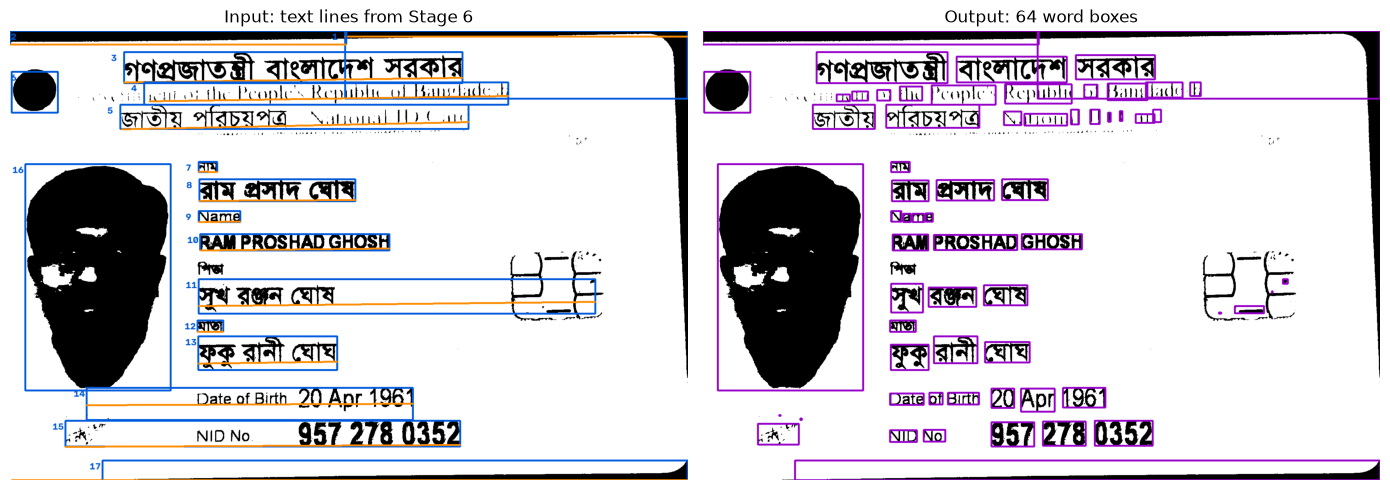

In [46]:
api.SetImageFile(IMG_PATH)
layout = api.AnalyseLayout()

words = []
if layout is not None:
    layout.Begin()
    while True:
        box = layout.BoundingBox(RIL.WORD)
        if box is not None:
            words.append({"box": box, "line": None})
        if not layout.Next(RIL.WORD):
            break


for w in words:
    wx0, wy0, wx1, wy1 = w["box"]
    wcx, wcy = (wx0 + wx1) / 2, (wy0 + wy1) / 2
    for i, ln in enumerate(lines, 1):
        lx0, ly0, lx1, ly1 = ln["box"]
        if lx0 <= wcx <= lx1 and ly0 <= wcy <= ly1:
            w["line"] = i
            break


gaps = []
for i in range(1, len(lines) + 1):
    row = sorted([w for w in words if w["line"] == i], key=lambda w: w["box"][0])
    for a, b in zip(row, row[1:]):
        gaps.append(b["box"][0] - a["box"][2])


print("Stage 7 output")
print(f"  Words found : {len(words)}")
if gaps:
    print(f"  Gap between neighbouring words (px): min {min(gaps)}, median {int(np.median(gaps))}, max {max(gaps)}")
print("\n  Words per line:")
for i, ln in enumerate(lines, 1):
    row = sorted([w for w in words if w["line"] == i], key=lambda w: w["box"][0])
    widths7 = ", ".join(str(w["box"][2] - w["box"][0]) for w in row)
    print(f"    line {i:2d}: {len(row)} word(s)   widths: {widths7}")
unassigned = sum(1 for w in words if w["line"] is None)
if unassigned:
    print(f"    ({unassigned} word(s) did not fall inside any line box)")
print("\n  Passed to Stage 8 -> words")

overlay7 = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2RGB)
for w in words:
    wx0, wy0, wx1, wy1 = w["box"]
    cv2.rectangle(overlay7, (wx0, wy0), (wx1, wy1), (150, 0, 200), BOX_THICKNESS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(overlay6)
axes[0].set_title("Input: text lines from Stage 6")
axes[1].imshow(overlay7)
axes[1].set_title(f"Output: {len(words)} word boxes")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Stage 8: Line Image Preparation

Each text line is turned into a single image in the exact form the neural network expects. Three steps are applied, using the **grayscale** copy from Stage 1 rather than the binary image:

1. **Crops the line:** cuts the line's bounding box out of the grayscale image.
2. **Scales to a fixed height:** resizes the crop to the height the network was trained on (48 pixels for the LSTM engine), keeping the aspect ratio so the width varies with the line's length.
3. **Normalizes brightness:** shifts the pixel values into the range the network expects.

*Note: Tesseract builds these line images internally and does not expose them, so this cell reconstructs the step using the same inputs and operations.*

Stage 8 output
  Prepared images   : 64
  Network height    : 48 px   [assumed - read from the model's network shape]
  Padding           : 4 px
  Value range       : -1.00 to 1.00

  Cropped size -> network input size (first 12):
     1. line   1   909 x 183 px  ->   238 x 48 px   black=229.0 white=233.0
     2. line   2   892 x  40 px  ->  1070 x 48 px   black= 24.0 white= 65.0
     3. line   3   354 x  90 px  ->   189 x 48 px   black= 60.8 white=196.0
     4. line   3   299 x  76 px  ->   189 x 48 px   black= 57.0 white=205.0
     5. line   1   217 x  72 px  ->   145 x 48 px   black= 53.5 white=201.0
     6. line   4    43 x  26 px  ->    79 x 48 px   black=179.5 white=209.2
     7. line   4    50 x  32 px  ->    75 x 48 px   black=167.0 white=210.5
     8. line   4    43 x  36 px  ->    57 x 48 px   black=163.8 white=219.0
     9. line   4    67 x  45 px  ->    71 x 48 px   black=156.5 white=210.0
    10. line   4   177 x  59 px  ->   144 x 48 px   black=169.8 white=218.0
    11. l

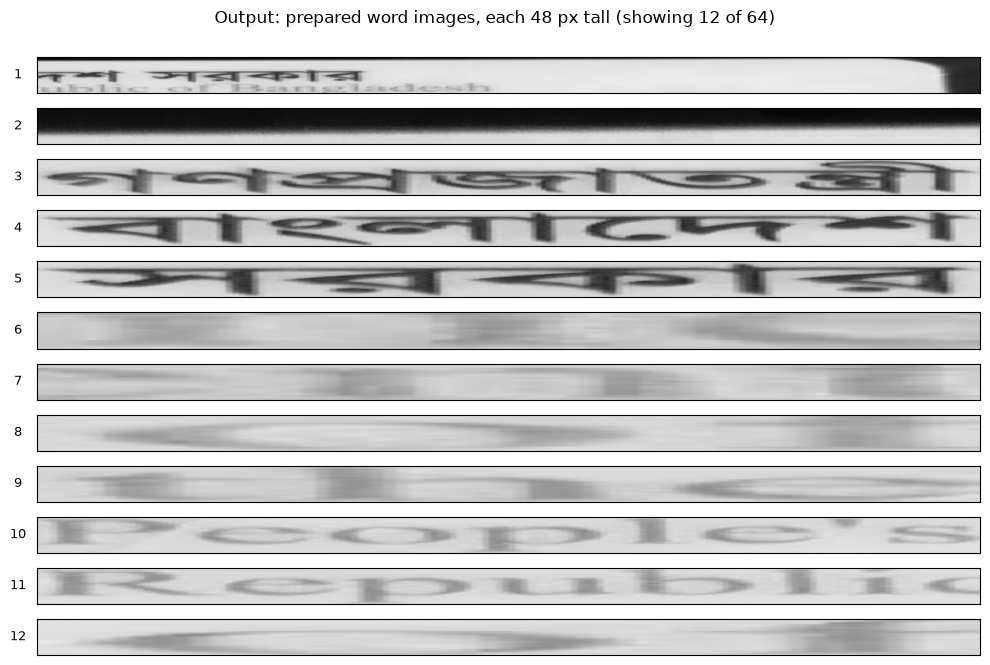

In [47]:
NETWORK_HEIGHT = 48
PAD = 4
MAX_SHOWN = 12

def compute_black_white(strip):
    """Approximates Tesseract's ComputeBlackWhite: takes the middle row,
    finds local minima and maxima, and uses their percentiles as the
    black and white points."""
    row = strip[strip.shape[0] // 2].astype(np.float32)
    if row.size < 3:
        return float(row.min()), float(max(row.max(), row.min() + 1))
    left, mid, right = row[:-2], row[1:-1], row[2:]
    minima = mid[(mid <= left) & (mid <= right)]
    maxima = mid[(mid >= left) & (mid >= right)]
    if minima.size == 0:
        minima = row
    if maxima.size == 0:
        maxima = row
    black = float(np.percentile(minima, 25))
    white = float(np.percentile(maxima, 75))
    if white - black < 1.0:
        black, white = float(row.min()), float(max(row.max(), row.min() + 1))
    return black, white

H, W = gray.shape
prepared = []
for w in words:
    wx0, wy0, wx1, wy1 = w["box"]

    cx0, cy0 = max(wx0 - PAD, 0), max(wy0 - PAD, 0)
    cx1, cy1 = min(wx1 + PAD, W), min(wy1 + PAD, H)
    crop = gray[cy0:cy1, cx0:cx1]
    if crop.size == 0 or crop.shape[0] < 2:
        continue


    ch, cw = crop.shape
    new_w = max(1, round(cw * NETWORK_HEIGHT / ch))
    resized = cv2.resize(crop, (new_w, NETWORK_HEIGHT), interpolation=cv2.INTER_AREA)


    black, white = compute_black_white(resized)
    normalized = np.clip(2.0 * (resized.astype(np.float32) - black) / (white - black) - 1.0, -1.0, 1.0)

    prepared.append({
        "pixels": normalized, "display": resized, "w": new_w,
        "src": (cw, ch), "line": w["line"], "black": black, "white": white,
    })


print("Stage 8 output")
print(f"  Prepared images   : {len(prepared)}")
print(f"  Network height    : {NETWORK_HEIGHT} px   [assumed - read from the model's network shape]")
print(f"  Padding           : {PAD} px")
print(f"  Value range       : {prepared[0]['pixels'].min():.2f} to {prepared[0]['pixels'].max():.2f}")
print("\n  Cropped size -> network input size (first 12):")
for i, p in enumerate(prepared[:MAX_SHOWN], 1):
    print(f"    {i:2d}. line {str(p['line']):>3}  {p['src'][0]:4d} x {p['src'][1]:3d} px  ->  "
          f"{p['w']:4d} x {NETWORK_HEIGHT} px   black={p['black']:5.1f} white={p['white']:5.1f}")
print("\n  Passed to Stage 9 -> prepared")

n = min(len(prepared), MAX_SHOWN)
fig, axes = plt.subplots(n, 1, figsize=(10, 0.55 * n))
axes = np.atleast_1d(axes)
for ax, p, i in zip(axes, prepared, range(1, n + 1)):
    ax.imshow(p["display"], cmap="gray", vmin=0, vmax=255, aspect="auto")
    ax.set_ylabel(f"{i}", rotation=0, labelpad=14, va="center", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle(f"Output: prepared word images, each {NETWORK_HEIGHT} px tall "
             f"(showing {n} of {len(prepared)})", y=1.0)
plt.tight_layout()
plt.show()

### Stage 9: LSTM Recognition

Each prepared line image is fed to the **LSTM network**, which reads it left to right:

1. **Steps across the line:** divides the image into narrow vertical slices, called time steps.
2. **Scores every character:** at each step, assigns a probability to every character in the model's character set, plus a blank symbol for "no character here".

The result is a table of probabilities with one row per time step and one column per character. No text has been chosen yet; that happens in Stage 10.

*Note: Tesseract does not expose the full probability table. What is shown below is the strongest few choices per time step, which is the closest view the API provides.*

Stage 9 output
  Characters committed : 191
  Confidence           : min 89.1, median 99.5, max 99.6
  Below 95%            : 11 of 191 characters

  Ten weakest characters:
      char    conf   in word
       'n'    89.1   an
       'e'    89.5   em
       '|'    90.4   |
       'র'    91.5   রী
       'i'    92.3   Ni
       'm'    93.2   em
       'i'    93.6   i
       'a'    94.2   an
       'ী'    94.4   রী
       'r'    94.7   Car

  Passed to Stage 10 -> symbols


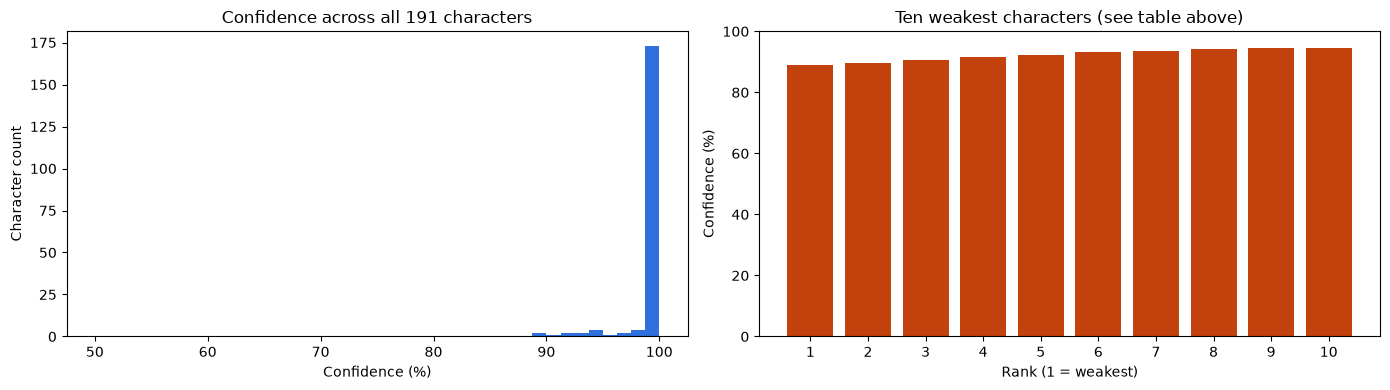

In [48]:
symbols = []
with PyTessBaseAPI(path=TESSDATA_DIR, lang=LANG, psm=PSM_MODE, oem=OEM_MODE) as rec_api:
    rec_api.SetImageFile(IMG_PATH)
    rec_api.Recognize()

    ri = rec_api.GetIterator()
    ri.Begin()
    while True:
        ch = ri.GetUTF8Text(RIL.SYMBOL)
        if ch and ch.strip():
            symbols.append({
                "char": ch,
                "conf": ri.Confidence(RIL.SYMBOL),
                "box": ri.BoundingBox(RIL.SYMBOL),
                "word": ri.GetUTF8Text(RIL.WORD).strip(),
            })
        if not ri.Next(RIL.SYMBOL):
            break

confs = np.array([s["conf"] for s in symbols])
print("Stage 9 output")
print(f"  Characters committed : {len(symbols)}")
print(f"  Confidence           : min {confs.min():.1f}, median {np.median(confs):.1f}, max {confs.max():.1f}")
print(f"  Below 95%            : {int(np.sum(confs < 95))} of {len(confs)} characters")

weakest = sorted(symbols, key=lambda s: s["conf"])[:10]
print("\n  Ten weakest characters:")
print(f"  {'char':>8}  {'conf':>6}   in word")
for s in weakest:
    print(f"  {repr(s['char']):>8}  {s['conf']:6.1f}   {s['word']}")

print("\n  Passed to Stage 10 -> symbols")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(confs, bins=40, range=(50, 100), color="#2f6fde")
axes[0].set_title(f"Confidence across all {len(confs)} characters")
axes[0].set_xlabel("Confidence (%)")
axes[0].set_ylabel("Character count")

axes[1].bar(range(len(weakest)), [s["conf"] for s in weakest], color="#c2410c")
axes[1].set_ylim(0, 100)
axes[1].set_xticks(range(len(weakest)))
axes[1].set_xticklabels([f"{i+1}" for i in range(len(weakest))])
axes[1].set_title("Ten weakest characters (see table above)")
axes[1].set_xlabel("Rank (1 = weakest)")
axes[1].set_ylabel("Confidence (%)")

plt.tight_layout()
plt.show()

### Stage 10: Decoding with Language Hints

The character probabilities are turned into actual text by a **beam search**, which keeps several candidate readings alive at once and picks the most likely one:

1. **Builds candidate sequences:** combines the scored characters into possible words, merging repeated characters and dropping the blank symbol.
2. **Applies language hints:** word lists and character patterns stored in the `.traineddata` file raise the score of sequences that look like real words.
3. **Commits the result:** keeps the highest-scoring sequence for each line and splits it into words.

**Output:** the recognized text, line by line and word by word, each with a position and a confidence score.

*Note: in the LSTM engine this step happens inside recognition rather than as a separate pass, so what is shown below is its committed result.*

Stage 10 output
  Language hints in effect:
    load_system_dawg                           = 1
    load_freq_dawg                             = 1
    load_number_dawg                           = 1
    load_punc_dawg                             = 1
    language_model_penalty_non_dict_word       = 0.15
    tessedit_char_whitelist                    = (not set)

  Lines decoded : 12
  Words decoded : 48

  Text line by line:
     1. [ 94.8%]  গণপ্রজাতন্ত্রী বাংলাদেশ সরকার
     2. [ 95.3%]  nent of the People's Republic of Bangladesh
     3. [ 67.0%]  em পরিচয়পত্র | Ni 1011 al IL ) Car d
     4. [ 96.3%]  নাম
     5. [ 96.0%]  রাম প্রসাদ ঘোষ
     6. [ 95.9%]  Name
     7. [ 92.1%]  RAM PROSHAD GHOSH
     8. [ 81.1%]  সুখ রঞ্জন ঘোষ রী
     9. [ 96.6%]  মাতা
    10. [ 91.6%]  ফুকু রানী ঘোঘ
    11. [ 89.0%]  i Date of Birth 20 Apr 1961
    12. [ 72.1%]  an nono 957 278 0352

  Words with positions:
    word                       conf   x     y     w     h
    গণপ্রজাতন্ত্রী             93.3 

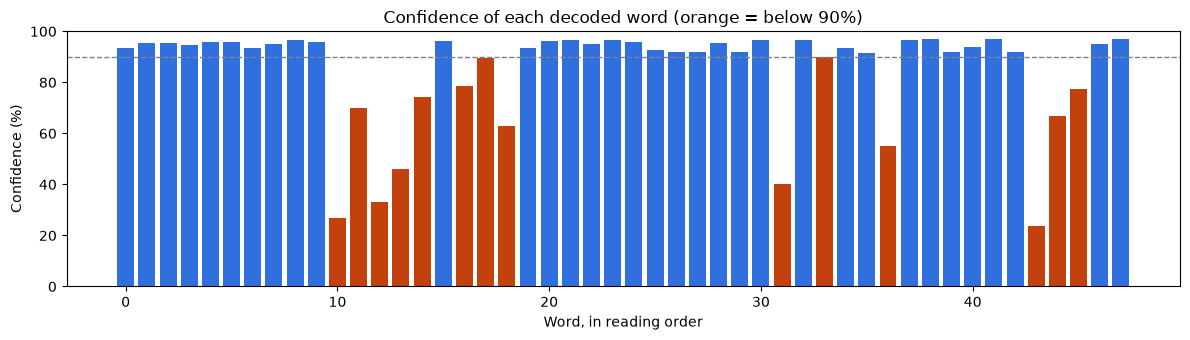

In [49]:
hint_vars = [
    "load_system_dawg",       
    "load_freq_dawg",         
    "load_number_dawg",
    "load_punc_dawg",
    "language_model_penalty_non_dict_word",
    "tessedit_char_whitelist",
]
settings = {}
with PyTessBaseAPI(path=TESSDATA_DIR, lang=LANG, psm=PSM_MODE, oem=OEM_MODE) as dec_api:
    dec_api.SetImageFile(IMG_PATH)
    dec_api.Recognize()
    for v in hint_vars:
        settings[v] = dec_api.GetVariableAsString(v)

    decoded_lines = []
    ri = dec_api.GetIterator()
    ri.Begin()
    while True:
        line_text = ri.GetUTF8Text(RIL.TEXTLINE)
        if line_text and line_text.strip():
            decoded_lines.append({
                "text": line_text.strip(),
                "conf": ri.Confidence(RIL.TEXTLINE),
                "box": ri.BoundingBox(RIL.TEXTLINE),
            })
        if not ri.Next(RIL.TEXTLINE):
            break

    decoded_words = []
    ri = dec_api.GetIterator()
    ri.Begin()
    while True:
        w_text = ri.GetUTF8Text(RIL.WORD)
        if w_text and w_text.strip():
            decoded_words.append({
                "text": w_text.strip(),
                "conf": ri.Confidence(RIL.WORD),
                "box": ri.BoundingBox(RIL.WORD),
            })
        if not ri.Next(RIL.WORD):
            break


print("Stage 10 output")
print("  Language hints in effect:")
for k, v in settings.items():
    shown = v if v not in ("", None) else "(not set)"
    print(f"    {k:42s} = {shown}")

print(f"\n  Lines decoded : {len(decoded_lines)}")
print(f"  Words decoded : {len(decoded_words)}")

print("\n  Text line by line:")
for i, ln in enumerate(decoded_lines, 1):
    print(f"    {i:2d}. [{ln['conf']:5.1f}%]  {ln['text']}")

print("\n  Words with positions:")
print(f"    {'word':<24} {'conf':>6}   x     y     w     h")
for w in decoded_words:
    bx0, by0, bx1, by1 = w["box"]
    print(f"    {w['text']:<24} {w['conf']:6.1f}  {bx0:4d}  {by0:4d}  {bx1-bx0:4d}  {by1-by0:4d}")

print("\n  Passed to Stage 11 -> decoded_words, decoded_lines")

plt.figure(figsize=(12, 3.5))
w_confs = [w["conf"] for w in decoded_words]
colours = ["#c2410c" if c < 90 else "#2f6fde" for c in w_confs]
plt.bar(range(len(w_confs)), w_confs, color=colours)
plt.ylim(0, 100)
plt.axhline(90, color="gray", linestyle="--", linewidth=1)
plt.title("Confidence of each decoded word (orange = below 90%)")
plt.xlabel("Word, in reading order")
plt.ylabel("Confidence (%)")
plt.tight_layout()
plt.show()

### Stage 11: Result Assembly and Output

The recognized words are assembled into a structured document and written out:

1. **Builds the hierarchy:** arranges the results as page → block → paragraph → line → word, using the reading order set in Stage 5.
2. **Detects paragraphs:** groups consecutive lines into paragraphs based on their indentation and spacing.
3. **Writes the chosen format:** renders the result as plain text, or as a format that also carries positions and confidences.

**Output:** the final result in the requested format — TXT, TSV, hOCR, ALTO or a searchable PDF.

Stage 11 output
  Hierarchy built:
    level 1 - page      : 1
    level 2 - block     : 16
    level 3 - paragraph : 16
    level 4 - line      : 17
    level 5 - word      : 53

  Plain text  : 248 characters
  TSV         : 103 rows
  hOCR        : 9046 characters of HTML

  Structured result (block / paragraph / line / word):
    b3 p1 l1 w 1  [ 93.3%]  x= 294 y=  52 w= 355 h=122  গণপ্রজাতন্ত্রী
    b3 p1 l1 w 2  [ 95.6%]  x= 671 y=  68 w= 291 h= 68  বাংলাদেশ
    b3 p1 l1 w 3  [ 95.4%]  x= 986 y=  64 w= 209 h= 64  সরকার
    b4 p1 l1 w 1  [ 94.8%]  x= 354 y= 160 w=  83 h= 26  nent
    b4 p1 l1 w 2  [ 95.6%]  x= 461 y= 156 w=  35 h= 28  of
    b4 p1 l1 w 3  [ 95.6%]  x= 521 y= 147 w=  59 h= 37  the
    b4 p1 l1 w 4  [ 93.6%]  x= 605 y= 144 w= 169 h= 51  People's
    b4 p1 l1 w 5  [ 94.9%]  x= 799 y= 141 w= 176 h= 51  Republic
    b4 p1 l1 w 6  [ 96.8%]  x=1008 y= 142 w=  35 h= 34  of
    b4 p1 l1 w 7  [ 96.0%]  x=1070 y= 136 w= 246 h= 47  Bangladesh
    b5 p1 l1 w 1  [ 26.7%]  x= 249

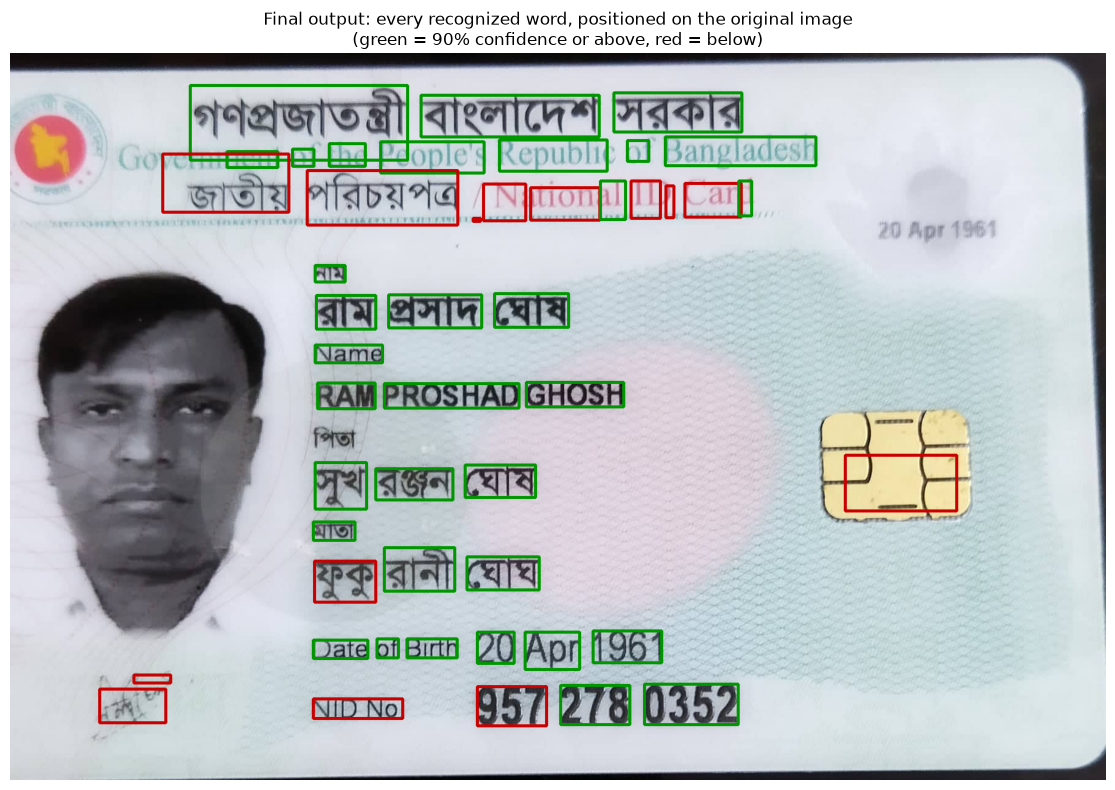

In [50]:
with PyTessBaseAPI(path=TESSDATA_DIR, lang=LANG, psm=PSM_MODE, oem=OEM_MODE) as out_api:
    out_api.SetImageFile(IMG_PATH)
    out_api.Recognize()
    txt_out = out_api.GetUTF8Text()
    tsv_out = out_api.GetTSVText(0)
    hocr_out = out_api.GetHOCRText(0)

COLS = ["level", "page_num", "block_num", "par_num", "line_num", "word_num",
        "left", "top", "width", "height", "conf", "text"]
INT_COLS = COLS[:10]

rows = []
for raw in tsv_out.splitlines():
    if not raw.strip():
        continue
    parts = raw.split("\t", 11)
    if len(parts) < 11:
        continue
    if parts[0] == "level":
        continue
    row = dict(zip(COLS, parts + [""] * (12 - len(parts))))
    try:
        for c in INT_COLS:
            row[c] = int(row[c])
        row["conf"] = float(row["conf"])
    except ValueError:
        continue
    rows.append(row)


level_names = {1: "page", 2: "block", 3: "paragraph", 4: "line", 5: "word"}
word_rows = [r for r in rows if r["level"] == 5 and r["text"].strip()]


print("Stage 11 output")
print("  Hierarchy built:")
for lvl in sorted(level_names):
    print(f"    level {lvl} - {level_names[lvl]:10s}: {sum(1 for r in rows if r['level'] == lvl)}")

print(f"\n  Plain text  : {len(txt_out.strip())} characters")
print(f"  TSV         : {len(rows)} rows")
print(f"  hOCR        : {len(hocr_out)} characters of HTML")

print("\n  Structured result (block / paragraph / line / word):")
for r in word_rows:
    print(f"    b{r['block_num']} p{r['par_num']} l{r['line_num']} w{r['word_num']:2d}  "
          f"[{r['conf']:5.1f}%]  x={r['left']:4d} y={r['top']:4d} "
          f"w={r['width']:4d} h={r['height']:3d}  {r['text']}")

print("\n  Plain text output:")
for line in txt_out.strip().splitlines():
    if line.strip():
        print(f"    {line}")

overlay11 = np.array(pil_img.convert("RGB")).copy()
for r in word_rows:
    colour = (200, 0, 0) if r["conf"] < 90 else (0, 150, 0)
    cv2.rectangle(overlay11, (r["left"], r["top"]),
                  (r["left"] + r["width"], r["top"] + r["height"]),
                  colour, BOX_THICKNESS)

plt.figure(figsize=(13, 8))
plt.imshow(overlay11)
plt.title("Final output: every recognized word, positioned on the original image\n"
          "(green = 90% confidence or above, red = below)")
plt.axis("off")
plt.tight_layout()
plt.show()